
# i) KNN algorithm on diabetes dataset[classification]
# ii) KNN algorithm on cardataset [Regression]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

# PART I

In [ ]:
df=pd.read_csv('/content/diabetes 4_KNN - diabetes 4_KNN.csv')

# EDA

In [ ]:
df.head()

,diabetes 4,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,169.5,33.6,0.627,50,1
2,1,85,66,29,102.5,26.6,0.351,31,0
3,8,183,64,32,169.5,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0


In [ ]:
df.tail()

,diabetes 4,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
764,10,101,76,48,180,32.9,0.171,63,0
765,2,122,70,27,102.5,36.8,0.34,27,0
766,5,121,72,23,112,26.2,0.245,30,0
767,1,126,60,32,169.5,30.1,0.349,47,1
768,1,93,70,31,102.5,30.4,0.315,23,0


In [ ]:
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,169.5,33.6,0.627,50,1
1,1,85,66,29,102.5,26.6,0.351,31,0
2,8,183,64,32,169.5,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.isnull().sum() # no null values in the dataset

,0
0,
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object', name=0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Pregnancies               768 non-null    object
 1   Glucose                   768 non-null    object
 2   BloodPressure             768 non-null    object
 3   SkinThickness             768 non-null    object
 4   Insulin                   768 non-null    object
 5   BMI                       768 non-null    object
 6   DiabetesPedigreeFunction  768 non-null    object
 7   Age                       768 non-null    object
 8   Outcome                   768 non-null    object
dtypes: object(9)
memory usage: 54.1+ KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768,768,768,768,768,768,768,768,768
unique,17,135,47,50,187,247,517,52,2
top,1,99,70,27,102.5,30.1,0.258,22,0
freq,135,17,76,162,236,18,6,72,500


In [ ]:
df.duplicated().sum() # no duplicates found

np.int64(0)

In [ ]:
df.nunique()

,0
0,
Pregnancies,17
Glucose,135
BloodPressure,47
SkinThickness,50
Insulin,187
BMI,247
DiabetesPedigreeFunction,517
Age,52
Outcome,2


### Data Type Conversion

All columns are currently of object type.  convert them to appropriate numerical types for analysis.

In [ ]:
for column in df.columns:
    if column != 'Outcome':
        df[column] = pd.to_numeric(df[column], errors='coerce')

# Check data types after conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 54.1+ KB


### Visualize Feature Distributions


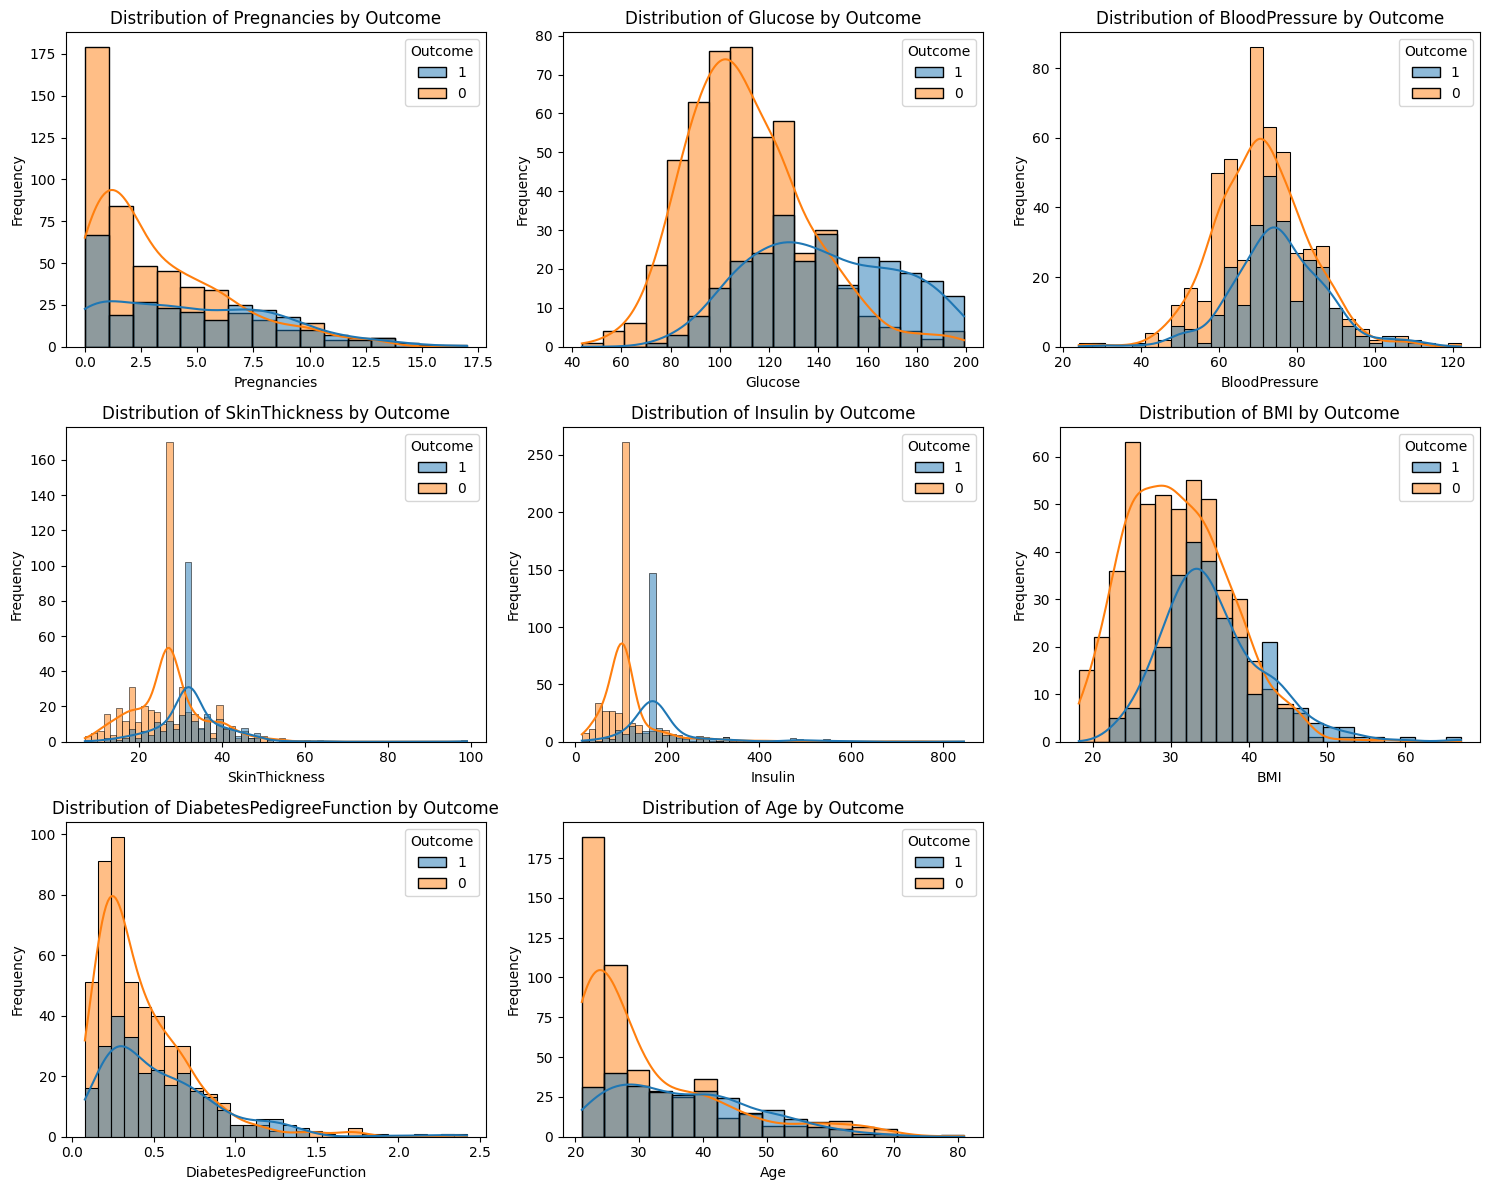

In [ ]:
numerical_features = df.drop(columns=['Outcome']).columns

plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(data=df, x=feature, hue='Outcome', kde=True)
    plt.title(f'Distribution of {feature} by Outcome')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

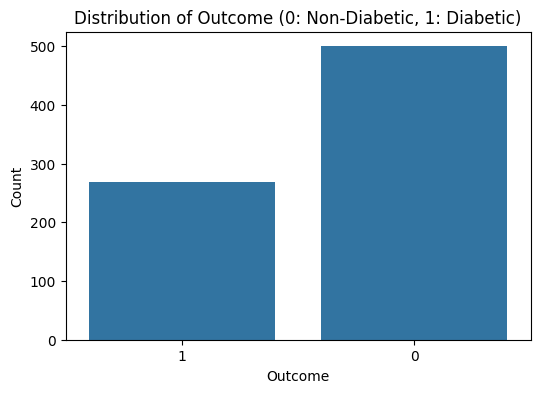

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome')
plt.title('Distribution of Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

# KNN algorithm to determine the outcome

In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)


In [ ]:
numerical_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = df[numerical_features]
Y = df['Outcome']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y , test_size = 0.2, random_state = 42)

In [ ]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,70.0,27,102.5,30.1,0.304,21
618,9,112,82.0,24,169.5,28.2,1.282,50
346,1,139,46.0,19,83.0,28.7,0.654,22
294,0,161,50.0,27,102.5,21.9,0.254,65
231,6,134,80.0,37,370.0,46.2,0.238,46


In [ ]:
y_train.head()

,Outcome
60,0
618,1
346,0
294,0
231,1


In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred=knn.predict(X_test)

In [ ]:
print(y_pred)

['1' '0' '0' '0' '0' '1' '0' '0' '1' '0' '1' '0' '0' '0' '0' '1' '0' '0'
 '1' '0' '0' '0' '0' '0' '1' '1' '0' '0' '0' '0' '1' '1' '1' '1' '0' '1'
 '1' '1' '0' '1' '0' '0' '0' '1' '0' '0' '0' '0' '0' '1' '0' '1' '1' '1'
 '0' '0' '0' '0' '0' '1' '1' '0' '0' '0' '0' '0' '0' '1' '0' '1' '1' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '1' '0' '0' '0' '0' '1' '1' '0' '0' '0'
 '0' '0' '0' '1' '1' '0' '0' '0' '1' '0' '0' '0' '1' '1' '1' '1' '0' '1'
 '0' '1' '0' '1' '0' '1' '1' '0' '1' '0' '0' '0' '0' '0' '1' '0' '0' '1'
 '1' '1' '1' '0' '1' '0' '1' '1' '1' '0' '1' '1' '1' '0' '0' '0' '0' '1'
 '0' '0' '1' '0' '0' '1' '0' '0' '0' '0']


In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",round(accuracy*100,2),"%")

Accuracy: 83.12 %


# PART II (Regression)

In [ ]:
data=pd.read_csv('/content/cardata - cardata.csv')

# EDA

In [ ]:
data.head()

,cardata,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
1,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
2,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
3,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
4,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0


In [ ]:
data.tail()

,cardata,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
297,city,2016,9.5,11.6,33988,Diesel,Dealer,Manual,0
298,brio,2015,4,5.9,60000,Petrol,Dealer,Manual,0
299,city,2009,3.35,11,87934,Petrol,Dealer,Manual,0
300,city,2017,11.5,12.5,9000,Diesel,Dealer,Manual,0
301,brio,2016,5.3,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   cardata     302 non-null    object
 1   Unnamed: 1  302 non-null    object
 2   Unnamed: 2  302 non-null    object
 3   Unnamed: 3  302 non-null    object
 4   Unnamed: 4  302 non-null    object
 5   Unnamed: 5  302 non-null    object
 6   Unnamed: 6  302 non-null    object
 7   Unnamed: 7  302 non-null    object
 8   Unnamed: 8  302 non-null    object
dtypes: object(9)
memory usage: 21.4+ KB


### Convert the data type of colms in the dataset

In [ ]:
data.columns = data.iloc[0]
data = data[1:].reset_index(drop=True)

print("Car data head after setting correct columns:")
(data.head())

Car data head after setting correct columns:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.6,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Identify columns that should be numeric
numerical_cols_car = ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']

for col in numerical_cols_car:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("Car data info after type conversion:")
data.info()

Car data info after type conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


###Data Visualisation

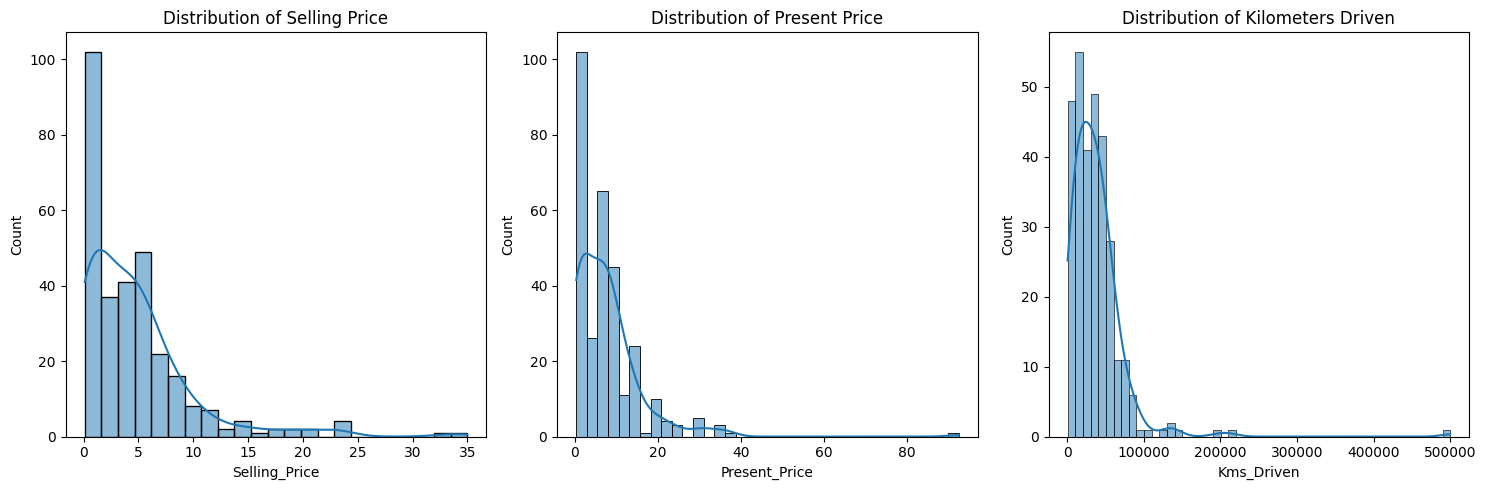

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(data['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price')

plt.subplot(1, 3, 2)
sns.histplot(data['Present_Price'], kde=True)
plt.title('Distribution of Present Price')

plt.subplot(1, 3, 3)
sns.histplot(data['Kms_Driven'], kde=True)
plt.title('Distribution of Kilometers Driven')

plt.tight_layout()
plt.show()

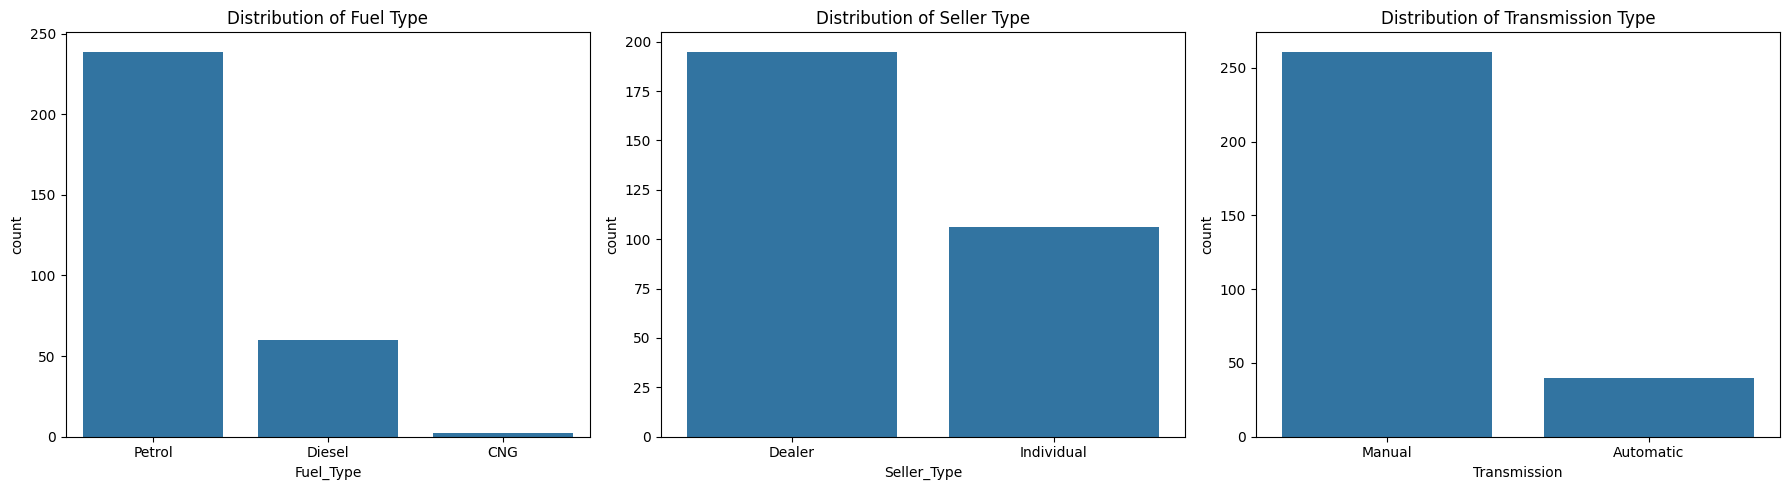

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=data, x='Fuel_Type')
plt.title('Distribution of Fuel Type')

plt.subplot(1, 3, 2)
sns.countplot(data=data, x='Seller_Type')
plt.title('Distribution of Seller Type')

plt.subplot(1, 3, 3)
sns.countplot(data=data, x='Transmission')
plt.title('Distribution of Transmission Type')

plt.tight_layout()
plt.show()

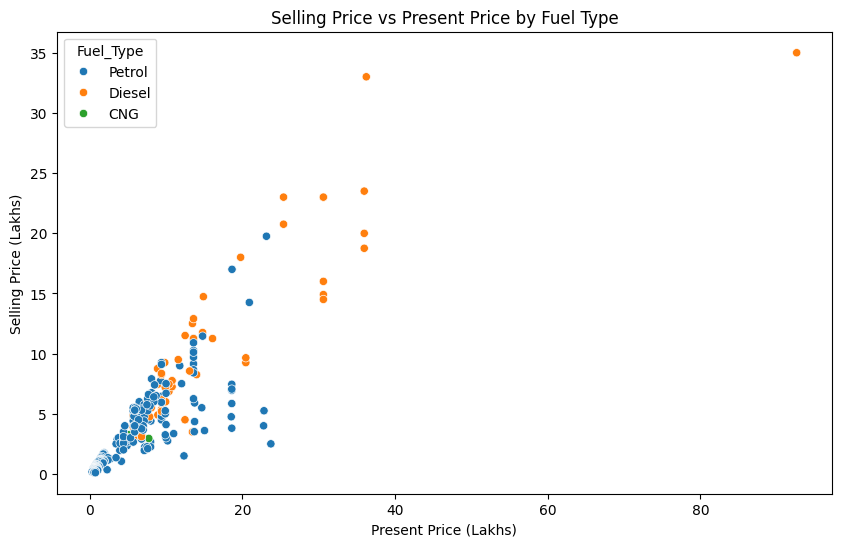

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Present_Price', y='Selling_Price', hue='Fuel_Type')
plt.title('Selling Price vs Present Price by Fuel Type')
plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

In [ ]:
#  Encode Categorical Features
data_encoded = pd.get_dummies(data, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)
X_car = data_encoded.drop(['Selling_Price', 'Car_Name'], axis=1)
y_car = data_encoded['Selling_Price']



In [ ]:
print("Features head after encoding:")
display(X_car.head())


Features head after encoding:


,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,5.59,27000,0,False,True,False,True
1,2013,9.54,43000,0,True,False,False,True
2,2017,9.85,6900,0,False,True,False,True
3,2011,4.15,5200,0,False,True,False,True
4,2014,6.87,42450,0,True,False,False,True


In [ ]:
print("Target head:")
display(y_car.head())

Target head:


,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


In [ ]:
# 3. Feature Scaling

numerical_cols_to_scale = ['Year', 'Present_Price', 'Kms_Driven', 'Owner']

scaler_car = StandardScaler()
X_car_scaled = X_car.copy()
X_car_scaled[numerical_cols_to_scale] = scaler_car.fit_transform(X_car_scaled[numerical_cols_to_scale])

print("Features (X_car) head after scaling:")
display(X_car_scaled.head())

Features (X_car) head after scaling:


,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,0.128897,-0.236215,-0.256224,-0.174501,False,True,False,True
1,-0.217514,0.221505,0.155911,-0.174501,True,False,False,True
2,1.168129,0.257427,-0.773969,-0.174501,False,True,False,True
3,-0.910335,-0.403079,-0.817758,-0.174501,False,True,False,True
4,0.128897,-0.087890,0.141743,-0.174501,True,False,False,True


In [ ]:

X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(X_car_scaled, y_car, test_size=0.2, random_state=42)

print(f"X_train_car shape: {X_train_car.shape}")
print(f"X_test_car shape: {X_test_car.shape}")
print(f"y_train_car shape: {y_train_car.shape}")
print(f"y_test_car shape: {y_test_car.shape}")

X_train_car shape: (240, 8)
X_test_car shape: (61, 8)
y_train_car shape: (240,)
y_test_car shape: (61,)


### Apply KNN Regressor



In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_car, y_train_car)


y_pred_car = knn.predict(X_test_car)

print("Sample Predictions:")
print(y_pred_car[:10])

Sample Predictions:
[0.466 9.548 4.58  0.44  6.95  6.36  0.858 0.63  0.83  5.58 ]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the model with regression metrics
mae = mean_absolute_error(y_test_car, y_pred_car)
mse = mean_squared_error(y_test_car, y_pred_car)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_car, y_pred_car)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 0.61
Mean Squared Error (MSE): 1.22
Root Mean Squared Error (RMSE): 1.10
R-squared (R2): 0.95
